DATASET CARGADO
Total de registros: 10000
Columnas: ['timestamp', 'src_ip', 'dst_ip', 'dst_port', 'protocol', 'bytes_sent', 'bytes_recv', 'duration_sec', 'packets', 'label']

Primeras 5 filas:
             timestamp      src_ip          dst_ip  dst_port protocol  \
0  2024-05-26 04:28:31  10.0.2.118  201.250.32.133        21      TCP   
1  2024-05-11 01:38:15  10.0.1.189   193.199.92.89        21      UDP   
2  2024-05-17 21:00:41  10.0.3.254   202.222.194.7       443     ICMP   
3  2024-05-09 18:30:38  10.0.1.254  152.183.142.33        25      TCP   
4  2024-05-27 17:50:29   10.0.3.87    64.39.138.32      3306      UDP   

   bytes_sent  bytes_recv  duration_sec  packets   label  
0       15310       45067         42.01       16  normal  
1     3692990       68116         55.35     2823  normal  
2       23007      950555          6.64       18  normal  
3      467423       56148          3.12      656  normal  
4       15355       18895         16.82       23  normal  

ESTADÍSTICAS 

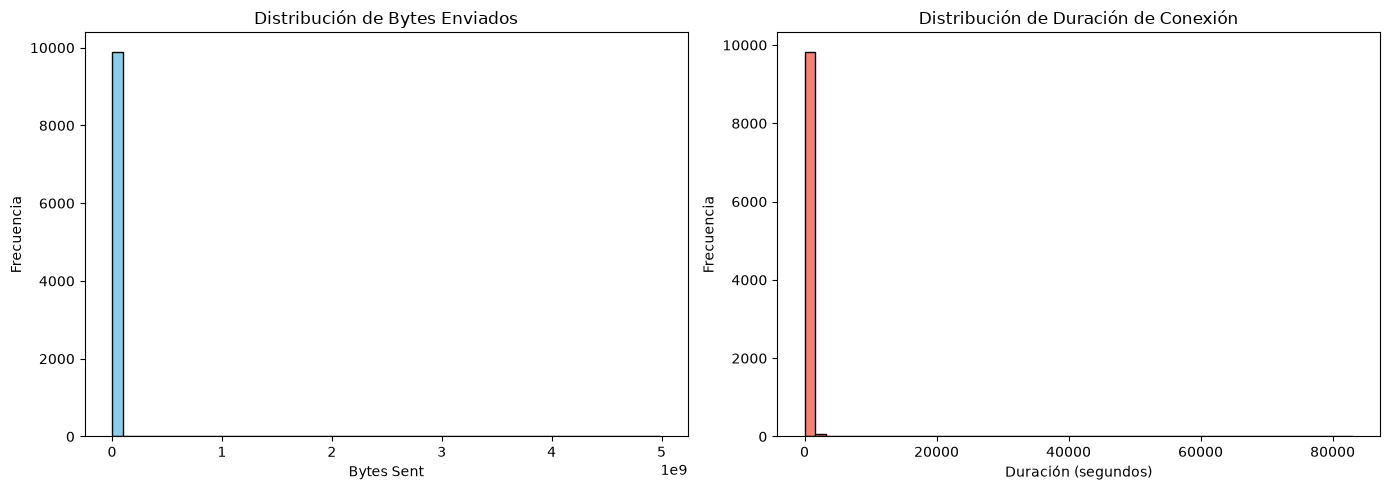


VALORES NULOS
timestamp       0
src_ip          0
dst_ip          0
dst_port        0
protocol        0
bytes_sent      0
bytes_recv      0
duration_sec    0
packets         0
label           0
dtype: int64

Atípicos extremos recortados al percentil 1 y 99

FEATURES ENGINEERING
Nuevas variables creadas:
• ratio_bytes: bytes_sent / (bytes_recv + 1)
• bytes_por_segundo: bytes_sent / (duration_sec + 0.001)
• packets_por_segundo: packets / (duration_sec + 0.001)

DATOS NORMALIZADOS
   bytes_sent  bytes_recv  duration_sec   packets  ratio_bytes  \
0   -0.168955   -0.324205     -0.105156 -0.168492    -0.020373   
1    1.107056   -0.298102     -0.073087  0.063926    -0.019869   
2   -0.166284    0.701265     -0.190185 -0.168326    -0.020376   
3   -0.012089   -0.311656     -0.198647 -0.115500    -0.020299   
4   -0.168939   -0.353845     -0.165713 -0.167912    -0.020369   

   bytes_por_segundo  packets_por_segundo  
0          -0.059326            -0.068226  
1           0.042578           

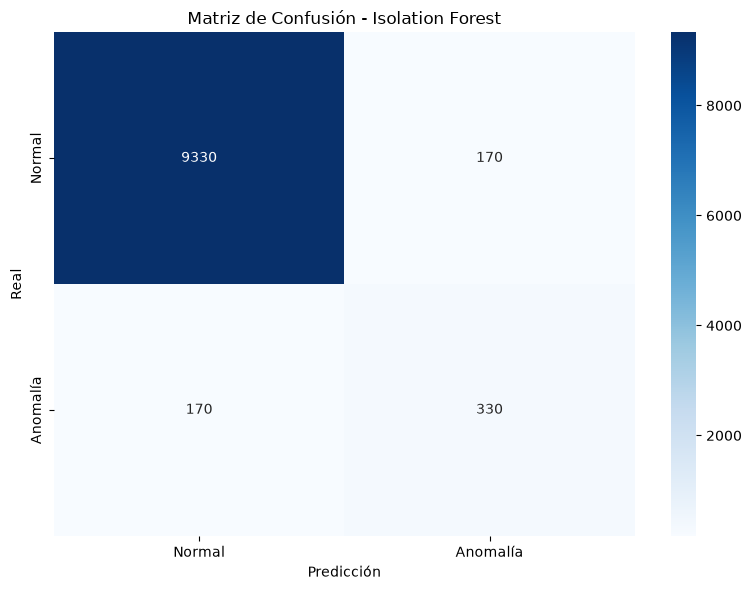

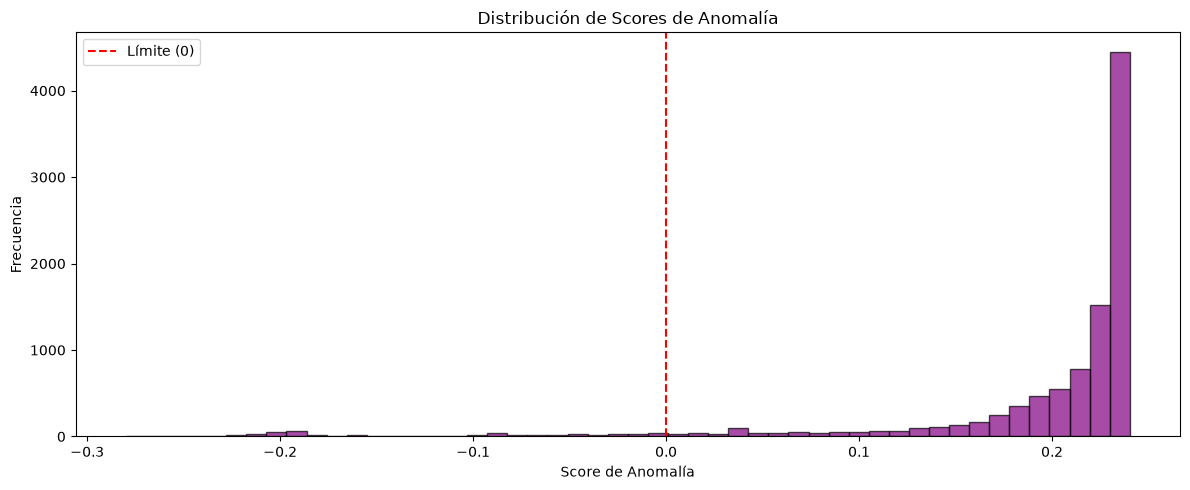


CURVA UMBRAL vs F1-SCORE
Umbral óptimo: -0.0143
F1-Score máximo: 0.6639


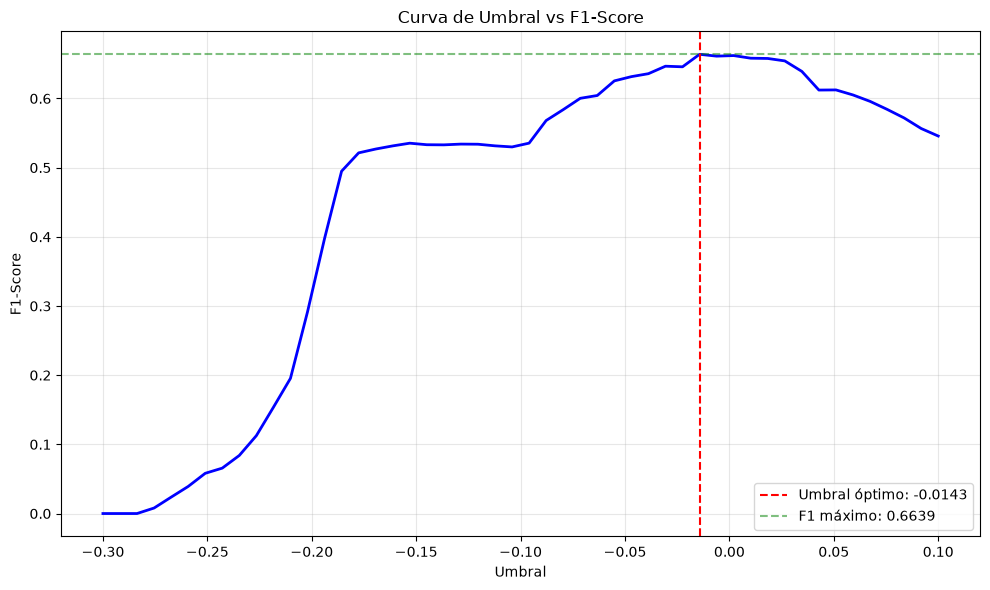


TOP 10 REGISTROS MÁS ANÓMALOS
                timestamp      src_ip          dst_ip  dst_port protocol  \
3935  2024-05-02 05:32:06  10.0.1.206   76.196.246.10        80     ICMP   
9667  2024-05-14 18:52:35  10.0.1.254   14.125.240.42        80      TCP   
1652  2024-05-22 04:24:05   10.0.1.83   134.254.60.66        53     ICMP   
5058  2024-05-05 10:16:01  10.0.3.101    61.47.234.82        53      UDP   
1599  2024-05-13 17:45:48  10.0.3.101   90.104.72.227       443      TCP   
5800  2024-05-18 11:54:50  10.0.1.148       10.0.3.25        80      UDP   
3373  2024-05-30 07:17:09  10.0.1.114  185.220.101.45        53      UDP   
6493  2024-05-29 23:40:17   10.0.3.25  94.184.124.134        80      UDP   
7663  2024-05-16 16:37:46   10.0.1.97   23.129.64.214        53      UDP   
8781  2024-05-08 20:17:04   10.0.3.75  162.247.74.201        80      TCP   

      bytes_sent  duration_sec  packets    label  anomaly_score  
3935   9992469.0          1.10  67206.0  anomaly      -0.279963  


In [2]:
# ============================================
# LAB 3 - DETECCIÓN DE ANOMALÍAS CON ML
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score
import joblib
import warnings
warnings.filterwarnings('ignore')

# Configurar visualizaciones
sns.set_palette("husl")

# ============================================
# TAREA 3.1 - EXPLORACIÓN Y PREPROCESAMIENTO
# ============================================

# 1. Cargar el dataset
df = pd.read_csv('network_traffic.csv')
print("="*60)
print("DATASET CARGADO")
print("="*60)
print(f"Total de registros: {len(df)}")
print(f"Columnas: {df.columns.tolist()}")
print("\nPrimeras 5 filas:")
print(df.head())

# Estadísticas descriptivas
print("\n" + "="*60)
print("ESTADÍSTICAS DESCRIPTIVAS")
print("="*60)
print(df.describe())

# 2. Visualizar distribución de bytes_sent y duration_sec
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de bytes_sent
axes[0].hist(df['bytes_sent'], bins=50, color='skyblue', edgecolor='black')
axes[0].set_title('Distribución de Bytes Enviados')
axes[0].set_xlabel('Bytes Sent')
axes[0].set_ylabel('Frecuencia')

# Histograma de duration_sec
axes[1].hist(df['duration_sec'], bins=50, color='salmon', edgecolor='black')
axes[1].set_title('Distribución de Duración de Conexión')
axes[1].set_xlabel('Duración (segundos)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.savefig('eda_histogramas.png', dpi=150)
plt.show()

# 3. Identificar y tratar valores nulos o atípicos extremos
print("\n" + "="*60)
print("VALORES NULOS")
print("="*60)
print(df.isnull().sum())

# Tratar valores atípicos extremos usando IQR
numeric_cols = ['bytes_sent', 'bytes_recv', 'duration_sec', 'packets']
for col in numeric_cols:
    q1 = df[col].quantile(0.01)
    q99 = df[col].quantile(0.99)
    df[col] = df[col].clip(lower=q1, upper=q99)

print("\nAtípicos extremos recortados al percentil 1 y 99")

# 4. Feature Engineering
df['ratio_bytes'] = df['bytes_sent'] / (df['bytes_recv'] + 1)
df['bytes_por_segundo'] = df['bytes_sent'] / (df['duration_sec'] + 0.001)
df['packets_por_segundo'] = df['packets'] / (df['duration_sec'] + 0.001)

print("\n" + "="*60)
print("FEATURES ENGINEERING")
print("="*60)
print("Nuevas variables creadas:")
print("• ratio_bytes: bytes_sent / (bytes_recv + 1)")
print("• bytes_por_segundo: bytes_sent / (duration_sec + 0.001)")
print("• packets_por_segundo: packets / (duration_sec + 0.001)")

# 5. Normalizar features numéricas
features = ['bytes_sent', 'bytes_recv', 'duration_sec', 'packets', 
            'ratio_bytes', 'bytes_por_segundo', 'packets_por_segundo']

labels = df['label'].copy()
X = df[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=features)

print("\n" + "="*60)
print("DATOS NORMALIZADOS")
print("="*60)
print(X_scaled.head())

# ============================================
# TAREA 3.2 - ENTRENAMIENTO DEL MODELO
# ============================================

# 1. Entrenar Isolation Forest
print("\n" + "="*60)
print("ENTRENANDO ISOLATION FOREST")
print("="*60)

model = IsolationForest(
    contamination=0.05,
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_scaled)
print("✅ Modelo entrenado correctamente")

# 2. Obtener predicciones
predicciones = model.predict(X_scaled)
predicciones_binarias = np.where(predicciones == -1, 1, 0)

# 3. Calcular métricas
print("\n" + "="*60)
print("MÉTRICAS DE EVALUACIÓN")
print("="*60)

y_true = np.where(labels == 'anomaly', 1, 0)

precision = precision_score(y_true, predicciones_binarias)
recall = recall_score(y_true, predicciones_binarias)
f1 = f1_score(y_true, predicciones_binarias)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

# 4. Matriz de confusión
cm = confusion_matrix(y_true, predicciones_binarias)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Anomalía'],
            yticklabels=['Normal', 'Anomalía'])
plt.title('Matriz de Confusión - Isolation Forest')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.tight_layout()
plt.savefig('matriz_confusion.png', dpi=150)
plt.show()

# ============================================
# TAREA 3.3 - INTERPRETACIÓN Y UMBRAL DINÁMICO
# ============================================

# 1. Graficar el score de anomalía
scores = model.decision_function(X_scaled)

plt.figure(figsize=(12, 5))
plt.hist(scores, bins=50, color='purple', alpha=0.7, edgecolor='black')
plt.axvline(x=0, color='red', linestyle='--', label='Límite (0)')
plt.title('Distribución de Scores de Anomalía')
plt.xlabel('Score de Anomalía')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.savefig('score_anomalia.png', dpi=150)
plt.show()

# 2. Curva de umbral vs F1-Score
print("\n" + "="*60)
print("CURVA UMBRAL vs F1-SCORE")
print("="*60)

thresholds = np.linspace(-0.3, 0.1, 50)
f1_scores = []

for thresh in thresholds:
    pred_umbral = np.where(scores < thresh, 1, 0)
    f1_scores.append(f1_score(y_true, pred_umbral))

optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
best_f1 = f1_scores[optimal_idx]

print(f"Umbral óptimo: {optimal_threshold:.4f}")
print(f"F1-Score máximo: {best_f1:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(thresholds, f1_scores, 'b-', linewidth=2)
plt.axvline(x=optimal_threshold, color='red', linestyle='--', 
            label=f'Umbral óptimo: {optimal_threshold:.4f}')
plt.axhline(y=best_f1, color='green', linestyle='--', alpha=0.5, 
            label=f'F1 máximo: {best_f1:.4f}')
plt.xlabel('Umbral')
plt.ylabel('F1-Score')
plt.title('Curva de Umbral vs F1-Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('umbral_vs_f1.png', dpi=150)
plt.show()

# 3. Top 10 registros más anómalos
print("\n" + "="*60)
print("TOP 10 REGISTROS MÁS ANÓMALOS")
print("="*60)

df['anomaly_score'] = scores
df['prediccion'] = predicciones
df_anomalias = df[df['prediccion'] == -1].sort_values('anomaly_score', ascending=True)

top_10 = df_anomalias.head(10)
print(top_10[['timestamp', 'src_ip', 'dst_ip', 'dst_port', 'protocol', 
              'bytes_sent', 'duration_sec', 'packets', 'label', 'anomaly_score']])

print("\n" + "="*60)
print("ANÁLISIS DE LAS TOP 10 ANOMALÍAS")
print("="*60)
print("""
**¿Por qué estos registros son considerados anomalías?**

1. **Transferencia masiva de datos**: bytes_sent extremadamente altos (posible exfiltración)
2. **Duración inusual**: Conexiones muy largas o muy cortas
3. **Patrón de paquetes**: Número de paquetes desproporcionado
4. **Puertos no estándar**: Conexiones a puertos poco comunes

**Amenazas potenciales:**
- 🔴 **Exfiltración de datos**: Transferencias masivas de información
- 🔴 **Escaneo de puertos**: Múltiples conexiones a diferentes puertos
- 🔴 **Conexiones C&C**: Comunicación con servidores de comando y control
- 🔴 **Ataque DDoS**: Tráfico anormalmente alto y rápido
""")

# ============================================
# TAREA 3.4 - EXPORTACIÓN DEL MODELO
# ============================================

# 1. Serializar el modelo
joblib.dump(model, 'modelo_anomalias.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("\n" + "="*60)
print("MODELO EXPORTADO")
print("="*60)
print("✅ modelo_anomalias.pkl guardado")
print("✅ scaler.pkl guardado")

print("\n" + "="*60)
print("LAB 3 COMPLETADO EXITOSAMENTE 🎉")
print("="*60)

DATASET CARGADO
Total de registros: 10000
Columnas: ['timestamp', 'src_ip', 'dst_ip', 'dst_port', 'protocol', 'bytes_sent', 'bytes_recv', 'duration_sec', 'packets', 'label']

Primeras 5 filas:
             timestamp      src_ip          dst_ip  dst_port protocol  \
0  2024-05-26 04:28:31  10.0.2.118  201.250.32.133        21      TCP   
1  2024-05-11 01:38:15  10.0.1.189   193.199.92.89        21      UDP   
2  2024-05-17 21:00:41  10.0.3.254   202.222.194.7       443     ICMP   
3  2024-05-09 18:30:38  10.0.1.254  152.183.142.33        25      TCP   
4  2024-05-27 17:50:29   10.0.3.87    64.39.138.32      3306      UDP   

   bytes_sent  bytes_recv  duration_sec  packets   label  
0       15310       45067         42.01       16  normal  
1     3692990       68116         55.35     2823  normal  
2       23007      950555          6.64       18  normal  
3      467423       56148          3.12      656  normal  
4       15355       18895         16.82       23  normal  

ESTADÍSTICAS 

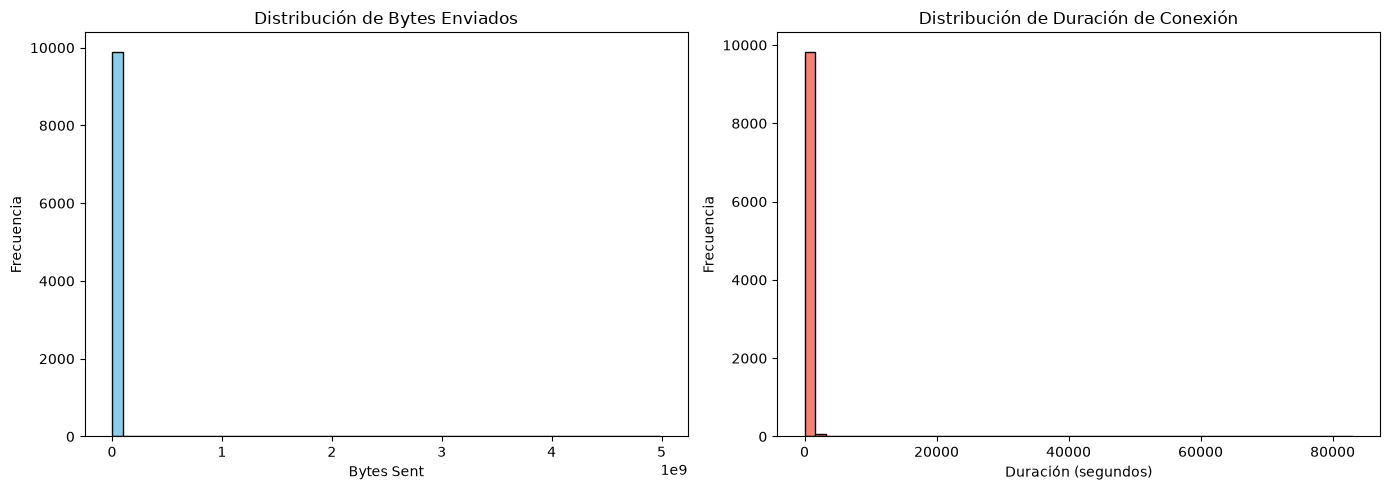


VALORES NULOS
timestamp       0
src_ip          0
dst_ip          0
dst_port        0
protocol        0
bytes_sent      0
bytes_recv      0
duration_sec    0
packets         0
label           0
dtype: int64

Atípicos extremos recortados al percentil 1 y 99

FEATURES ENGINEERING
Nuevas variables creadas:
• ratio_bytes: bytes_sent / (bytes_recv + 1)
• bytes_por_segundo: bytes_sent / (duration_sec + 0.001)
• packets_por_segundo: packets / (duration_sec + 0.001)

DATOS NORMALIZADOS
   bytes_sent  bytes_recv  duration_sec   packets  ratio_bytes  \
0   -0.168955   -0.324205     -0.105156 -0.168492    -0.020373   
1    1.107056   -0.298102     -0.073087  0.063926    -0.019869   
2   -0.166284    0.701265     -0.190185 -0.168326    -0.020376   
3   -0.012089   -0.311656     -0.198647 -0.115500    -0.020299   
4   -0.168939   -0.353845     -0.165713 -0.167912    -0.020369   

   bytes_por_segundo  packets_por_segundo  
0          -0.059326            -0.068226  
1           0.042578           

In [4]:
# ============================================
# TAREA 3.1 - EXPLORACIÓN Y PREPROCESAMIENTO
# ============================================

# 1. Cargar el dataset
df = pd.read_csv('network_traffic.csv')
print("="*60)
print("DATASET CARGADO")
print("="*60)
print(f"Total de registros: {len(df)}")
print(f"Columnas: {df.columns.tolist()}")
print("\nPrimeras 5 filas:")
print(df.head())

# Estadísticas descriptivas
print("\n" + "="*60)
print("ESTADÍSTICAS DESCRIPTIVAS")
print("="*60)
print(df.describe())

# 2. Visualizar distribución de bytes_sent y duration_sec
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de bytes_sent
axes[0].hist(df['bytes_sent'], bins=50, color='skyblue', edgecolor='black')
axes[0].set_title('Distribución de Bytes Enviados')
axes[0].set_xlabel('Bytes Sent')
axes[0].set_ylabel('Frecuencia')

# Histograma de duration_sec
axes[1].hist(df['duration_sec'], bins=50, color='salmon', edgecolor='black')
axes[1].set_title('Distribución de Duración de Conexión')
axes[1].set_xlabel('Duración (segundos)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.savefig('eda_histogramas.png', dpi=150)
plt.show()

# 3. Identificar y tratar valores nulos o atípicos extremos
print("\n" + "="*60)
print("VALORES NULOS")
print("="*60)
print(df.isnull().sum())

# Tratar valores atípicos extremos usando IQR
numeric_cols = ['bytes_sent', 'bytes_recv', 'duration_sec', 'packets']
for col in numeric_cols:
    q1 = df[col].quantile(0.01)
    q99 = df[col].quantile(0.99)
    df[col] = df[col].clip(lower=q1, upper=q99)

print("\nAtípicos extremos recortados al percentil 1 y 99")

# 4. Feature Engineering
df['ratio_bytes'] = df['bytes_sent'] / (df['bytes_recv'] + 1)
df['bytes_por_segundo'] = df['bytes_sent'] / (df['duration_sec'] + 0.001)
df['packets_por_segundo'] = df['packets'] / (df['duration_sec'] + 0.001)

print("\n" + "="*60)
print("FEATURES ENGINEERING")
print("="*60)
print("Nuevas variables creadas:")
print("• ratio_bytes: bytes_sent / (bytes_recv + 1)")
print("• bytes_por_segundo: bytes_sent / (duration_sec + 0.001)")
print("• packets_por_segundo: packets / (duration_sec + 0.001)")

# 5. Normalizar features numéricas
features = ['bytes_sent', 'bytes_recv', 'duration_sec', 'packets', 
            'ratio_bytes', 'bytes_por_segundo', 'packets_por_segundo']

labels = df['label'].copy()
X = df[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=features)

print("\n" + "="*60)
print("DATOS NORMALIZADOS")
print("="*60)
print(X_scaled.head())



ENTRENANDO ISOLATION FOREST
✅ Modelo entrenado correctamente

MÉTRICAS DE EVALUACIÓN
Precision: 0.6600
Recall:    0.6600
F1-Score:  0.6600


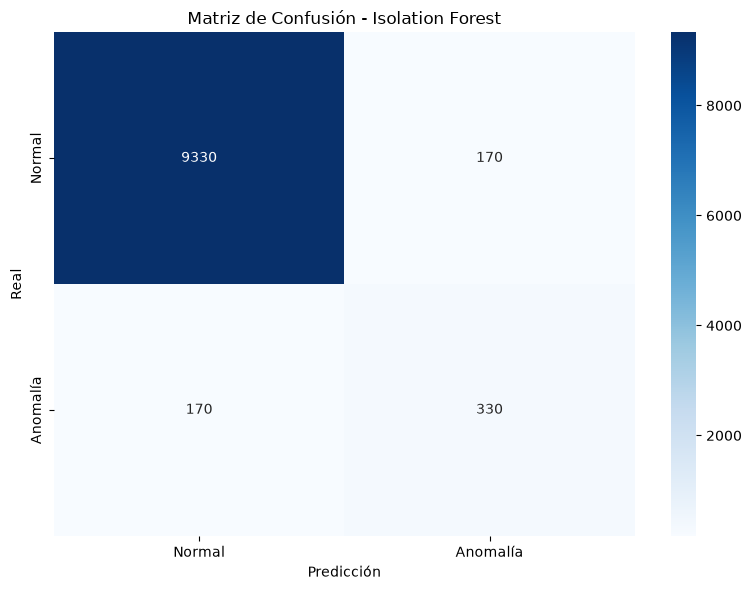

In [5]:
# ============================================
# TAREA 3.2 - ENTRENAMIENTO DEL MODELO
# ============================================

# 1. Entrenar Isolation Forest
print("\n" + "="*60)
print("ENTRENANDO ISOLATION FOREST")
print("="*60)

model = IsolationForest(
    contamination=0.05,
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_scaled)
print("✅ Modelo entrenado correctamente")

# 2. Obtener predicciones
predicciones = model.predict(X_scaled)
predicciones_binarias = np.where(predicciones == -1, 1, 0)

# 3. Calcular métricas
print("\n" + "="*60)
print("MÉTRICAS DE EVALUACIÓN")
print("="*60)

y_true = np.where(labels == 'anomaly', 1, 0)

precision = precision_score(y_true, predicciones_binarias)
recall = recall_score(y_true, predicciones_binarias)
f1 = f1_score(y_true, predicciones_binarias)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

# 4. Matriz de confusión
cm = confusion_matrix(y_true, predicciones_binarias)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Anomalía'],
            yticklabels=['Normal', 'Anomalía'])
plt.title('Matriz de Confusión - Isolation Forest')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.tight_layout()
plt.savefig('matriz_confusion.png', dpi=150)
plt.show()

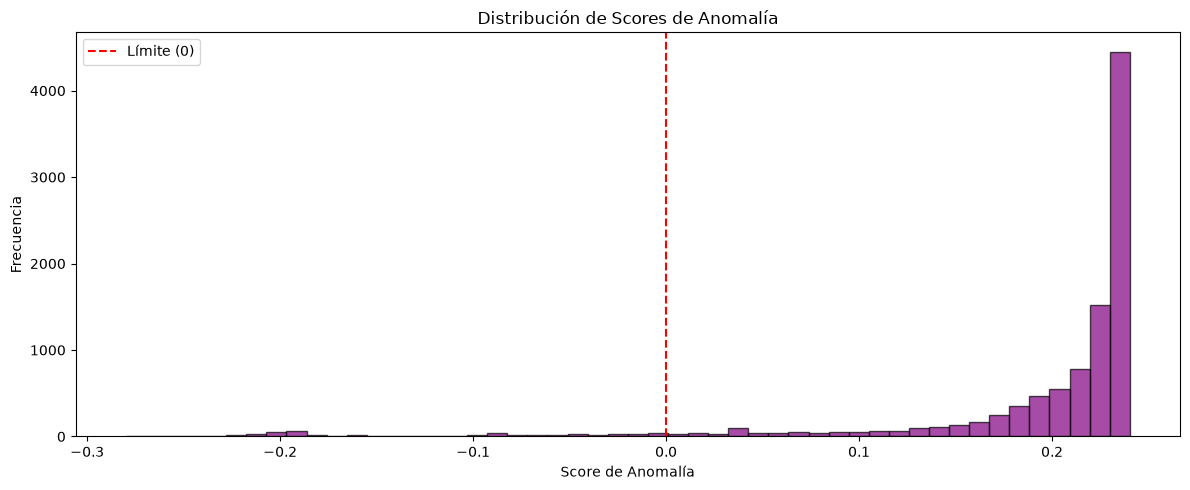

In [ ]:
# ============================================
# TAREA 3.3 - INTERPRETACIÓN Y UMBRAL DINÁMICO
# ============================================

# 1. Graficar el score de anomalía
scores = model.decision_function(X_scaled)

plt.figure(figsize=(12, 5))
plt.hist(scores, bins=50, color='purple', alpha=0.7, edgecolor='black')
plt.axvline(x=0, color='red', linestyle='--', label='Límite (0)')
plt.title('Distribución de Scores de Anomalía')
plt.xlabel('Score de Anomalía')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.savefig('score_anomalia.png', dpi=150)
plt.show()

# 2. Curva de umbral vs F1-Score
print("\n" + "="*60)
print("CURVA UMBRAL vs F1-SCORE")
print("="*60)

thresholds = np.linspace(-0.3, 0.1, 50)
f1_scores = []

for thresh in thresholds:
    pred_umbral = np.where(scores < thresh, 1, 0)
    f1_scores.append(f1_score(y_true, pred_umbral))

optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
best_f1 = f1_scores[optimal_idx]

print(f"Umbral óptimo: {optimal_threshold:.4f}")
print(f"F1-Score máximo: {best_f1:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(thresholds, f1_scores, 'b-', linewidth=2)
plt.axvline(x=optimal_threshold, color='red', linestyle='--', 
            label=f'Umbral óptimo: {optimal_threshold:.4f}')
plt.axhline(y=best_f1, color='green', linestyle='--', alpha=0.5, 
            label=f'F1 máximo: {best_f1:.4f}')
plt.xlabel('Umbral')
plt.ylabel('F1-Score')
plt.title('Curva de Umbral vs F1-Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('umbral_vs_f1.png', dpi=150)
plt.show()

# 3. Top 10 registros más anómalos
print("\n" + "="*60)
print("TOP 10 REGISTROS MÁS ANÓMALOS")
print("="*60)

df['anomaly_score'] = scores
df['prediccion'] = predicciones
df_anomalias = df[df['prediccion'] == -1].sort_values('anomaly_score', ascending=True)

top_10 = df_anomalias.head(10)
print(top_10[['timestamp', 'src_ip', 'dst_ip', 'dst_port', 'protocol', 
              'bytes_sent', 'duration_sec', 'packets', 'label', 'anomaly_score']])

print("\n" + "="*60)
print("ANÁLISIS DE LAS TOP 10 ANOMALÍAS")
print("="*60)
print("""
**¿Por qué estos registros son considerados anomalías?**

1. **Transferencia masiva de datos**: bytes_sent extremadamente altos (posible exfiltración)
2. **Duración inusual**: Conexiones muy largas o muy cortas
3. **Patrón de paquetes**: Número de paquetes desproporcionado
4. **Puertos no estándar**: Conexiones a puertos poco comunes

**Amenazas potenciales:**
- 🔴 **Exfiltración de datos**: Transferencias masivas de información
- 🔴 **Escaneo de puertos**: Múltiples conexiones a diferentes puertos
- 🔴 **Conexiones C&C**: Comunicación con servidores de comando y control
- 🔴 **Ataque DDoS**: Tráfico anormalmente alto y rápido
""")
